## 1. Install

In [1]:
!pip install -q ultralytics roboflow pyyaml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.9 MB/s eta 0:00:00


## 2. Imports

In [2]:
import os, glob, yaml, shutil
from collections import Counter, defaultdict
from getpass import getpass
import matplotlib.pyplot as plt
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Roboflow login

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="6GUvtYjBqEY4HVKIF4Zt")
project = rf.workspace("trash-dataset-for-oriented-bounded-box").project("trash-detection-1fjjc")
version = project.version(14)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Trash-Detection-14 in yolo26:: 100%|██████████| 13578/13578 [00:02<00:00, 6692.30it/s]


## 4. Download

In [4]:
DATASET_DIR = dataset.location
yaml_path = os.path.join(DATASET_DIR, "data.yaml")
print(DATASET_DIR)

/content/Trash-Detection-14


## 5. Check classes

In [5]:
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]
print(class_names)

['Glass', 'Metal', 'Paper', 'Plastic', 'Waste']


## 6. Dataset counts

In [6]:
for split in ["train", "valid", "test"]:
    print(split, ":", len(glob.glob(f"{DATASET_DIR}/{split}/images/*")))

train : 6000
valid : 673
test : 110


## 7. Object counts

In [7]:
def names_list(names):
    if isinstance(names, dict):
        return [names.get(i, names.get(str(i))) for i in range(len(names))]
    return list(names)

class_list = names_list(class_names)
class_counts = Counter()
images_per_class = defaultdict(set)
total_images = 0

for split in ["train", "valid", "test"]:
    total_images += len(glob.glob(f"{DATASET_DIR}/{split}/images/*"))

    for label_file in glob.glob(f"{DATASET_DIR}/{split}/labels/*.txt"):
        seen = set()

        for line in open(label_file):
            parts = line.split()
            if not parts:
                continue
            cid = int(parts[0])
            class_counts[cid] += 1
            seen.add(cid)

        for cid in seen:
            images_per_class[cid].add(label_file)

total_objects = sum(class_counts.values())

print("Total images:", total_images)
print("Total objects:", total_objects)
print("Average objects/image:", round(total_objects / total_images, 2))

for i, name in enumerate(class_list):
    print(f"{name}: {class_counts[i]} objects | {len(images_per_class[i])} images")


Total images: 6783
Total objects: 14631
Average objects/image: 2.16
Glass: 908 objects | 618 images
Metal: 1796 objects | 1170 images
Paper: 1396 objects | 1055 images
Plastic: 6727 objects | 4413 images
Waste: 3804 objects | 1560 images


## 8. Class chart

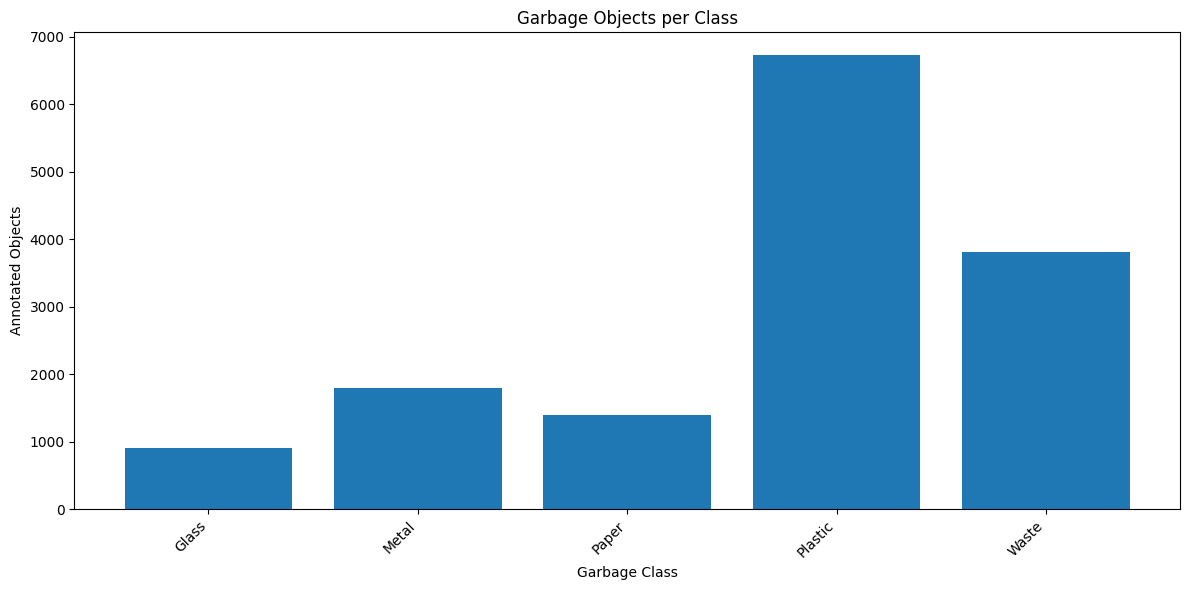

In [8]:
counts = [class_counts[i] for i in range(len(class_list))]

plt.figure(figsize=(12, 6))
plt.bar(class_list, counts)
plt.xlabel("Garbage Class")
plt.ylabel("Annotated Objects")
plt.title("Garbage Objects per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Baseline


image 1/1 /content/Trash-Detection-14/test/images/metal253_jpg.rf.24fed9107e040f81322d31f4acb83afd.jpg: 640x640 (no detections), 9.8ms
Speed: 76.5ms preprocess, 9.8ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


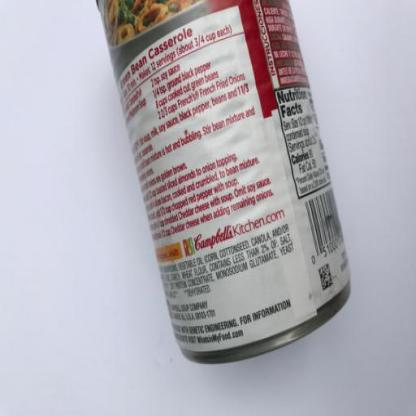

In [9]:
model = YOLO("yolo26n.pt")

test_images = glob.glob(f"{DATASET_DIR}/test/images/*")
if not test_images:
    raise ValueError("No test images found.")

baseline = model(test_images[0])
baseline[0].show()


## 10. Train with early stopping

In [10]:
shutil.rmtree("/content/runs/garbage_detection/v1", ignore_errors=True)

model = YOLO("yolo26n.pt")

model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=8,
    patience=15,
    project="/content/runs/garbage_detection",
    name="v1"
)

Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Trash-Detection-14/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1, nbs=64, nms=False, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d62215c6900>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

## 11. Load best model

In [11]:
best_path = "/content/runs/garbage_detection/v1/weights/best.pt"
v1_model = YOLO(best_path)
print(v1_model.names)

{0: 'Glass', 1: 'Metal', 2: 'Paper', 3: 'Plastic', 4: 'Waste'}


## 12. Evaluate

In [12]:
metrics = v1_model.val(data=yaml_path, split="test")

print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))


Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 926.7±687.4 MB/s, size: 30.8 KB)
val: Scanning /content/Trash-Detection-14/test/labels... 110 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 1.8Kit/s 0.1s
val: New cache created: /content/Trash-Detection-14/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.5it/s 2.8s
                   all        110        175      0.731      0.515      0.584      0.528
                 Glass         35         60      0.807      0.567      0.561      0.503
                 Metal         18         25      0.881      0.594      0.734      0.673
                 Paper         15         18      0.798      0.667      0.702      0.632
               Plastic         44         55      0.838      0.6

## 13. Per-class mAP50-95

In [13]:
for name, score in zip(v1_model.names.values(), metrics.box.maps):
    print(name, ":", round(float(score), 4))


Glass : 0.5035
Metal : 0.6732
Paper : 0.6317
Plastic : 0.7022
Waste : 0.1314


## 14. Test images


0: 640x640 1 Metal, 4.8ms
1: 640x640 1 Plastic, 4.8ms
2: 640x640 2 Plastics, 4.8ms
3: 640x640 4 Plastics, 4.8ms
4: 640x640 1 Plastic, 4.8ms
5: 640x640 (no detections), 4.8ms
6: 640x640 1 Glass, 1 Plastic, 4.8ms
7: 640x640 1 Metal, 4.8ms
8: 640x640 1 Metal, 4.8ms
9: 640x640 1 Plastic, 4.8ms
Speed: 2.8ms preprocess, 4.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


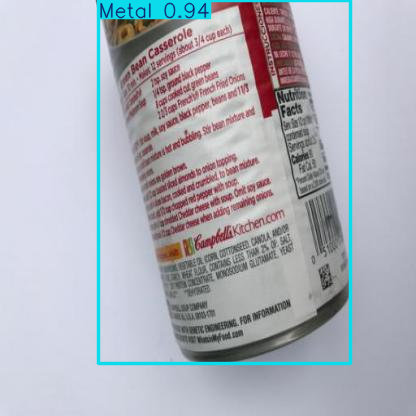

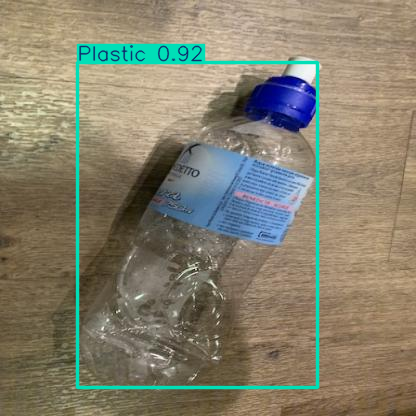

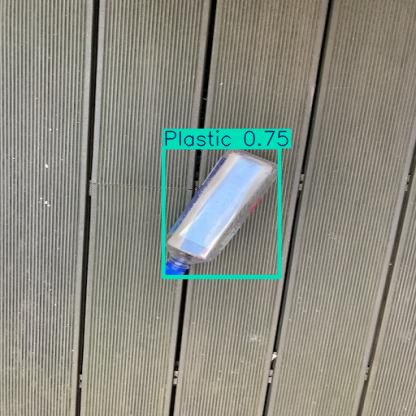

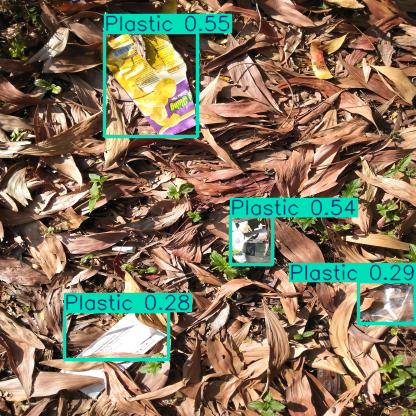

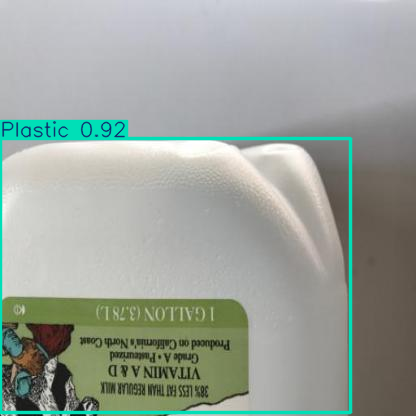

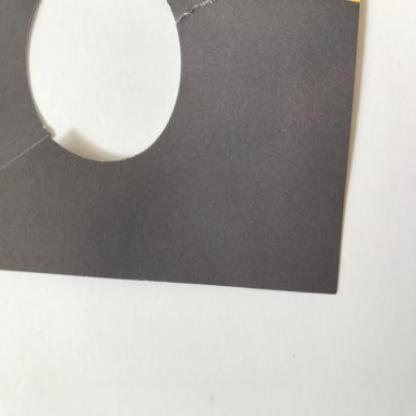

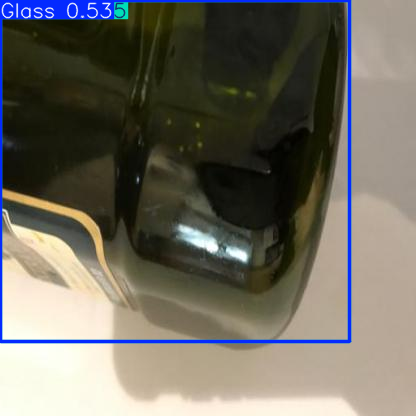

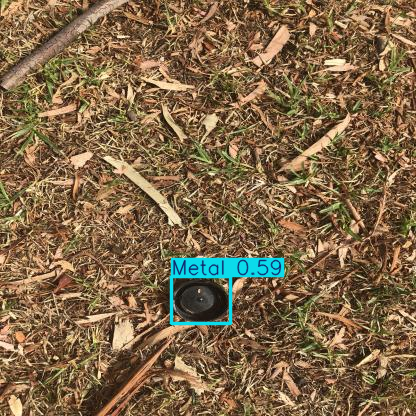

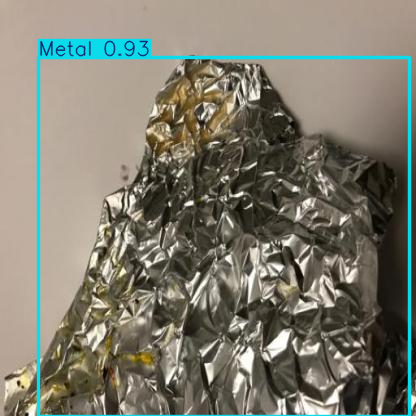

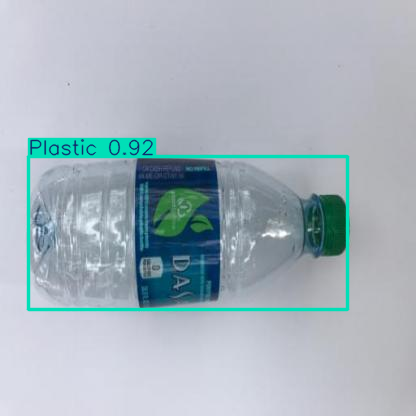

In [14]:
results = v1_model(test_images[:10], conf=0.25)

for result in results:
    result.show()


## 15. Camera setup

In [15]:
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Javascript, display

def take_photo(filename="camera_test.jpg"):
    js = Javascript("""
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');

      button.textContent = 'Take Photo';
      div.appendChild(video);
      div.appendChild(document.createElement('br'));
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      await new Promise(resolve => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }
    """)

    display(js)
    data = eval_js("takePhoto()")
    binary = b64decode(data.split(",")[1])

    with open(filename, "wb") as f:
        f.write(binary)

    return filename


## 16. Camera detection

In [16]:
camera_image = take_photo()

result = v1_model(camera_image, conf=0.25)
result[0].show()

if len(result[0].boxes) == 0:
    print("No detections.")
else:
    for box in result[0].boxes:
        cid = int(box.cls[0])
        conf = float(box.conf[0])
        print(v1_model.names[cid], f"{conf * 100:.1f}%")

<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied